# The Geometric Inversion of SHA-256 as a Switched Reluctance Machine  
## Full Research Notebook

This notebook is the **runnable companion** to the paper **_The Geometric Inversion of SHA-256 as a Switched Reluctance Machine_**.

It is organized as a **locked, auditable, end-to-end notebook** in the same style as prior Nexus notebooks:

- explicit constants and invariants at the top,
- full executable code rather than snippets,
- direct reproduction of the phase-angle / coupling / carry-terrain results,
- plots and tables generated from the code,
- clean separation between **verified diagnostics** and **open research hooks**.

### Core targets
1. Reproduce the **NOP manifold** and the phase-angle corridor.
2. Measure **commutation / power-stroke rounds**.
3. Measure **non-uniform bit coupling** and the hot-bit clusters.
4. Search for sparse **W0 injections** that drive the system toward **MARK1 = π/9**.
5. Expose the die as a **sparse folded lattice** with two nonlinear reinjection heads.
6. Provide a reproducible scaffold for **single-block forward traces** and bridge-oriented diagnostics.

### What this notebook treats as locked
- `H0` and `K` are the FIPS SHA-256 anchors.
- `T1` is the active signal / stator-like channel.
- `T2` is the restoring / rotor-like channel.
- The phase-angle / coupling diagnostics are measured directly from the executable recurrence.
- The notebook is **not** a rhetorical paper renderer; it is a computation surface.


In [1]:

# Cell 1 — Environment & Imports

import math
import hashlib
import random
from dataclasses import dataclass
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
random.seed(42)

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True

print("Python notebook runtime ready.")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)


Python notebook runtime ready.
NumPy: 2.3.5
pandas: 2.2.3


In [2]:

# Cell 2 — Locked Parameters / Constants

MASK = 0xFFFFFFFF
WORD_BITS = 32
ROUNDS = 64

H0 = [
    0x6a09e667, 0xbb67ae85, 0x3c6ef372, 0xa54ff53a,
    0x510e527f, 0x9b05688c, 0x1f83d9ab, 0x5be0cd19,
]

K = [
    0x428a2f98,0x71374491,0xb5c0fbcf,0xe9b5dba5,0x3956c25b,0x59f111f1,0x923f82a4,0xab1c5ed5,
    0xd807aa98,0x12835b01,0x243185be,0x550c7dc3,0x72be5d74,0x80deb1fe,0x9bdc06a7,0xc19bf174,
    0xe49b69c1,0xefbe4786,0x0fc19dc6,0x240ca1cc,0x2de92c6f,0x4a7484aa,0x5cb0a9dc,0x76f988da,
    0x983e5152,0xa831c66d,0xb00327c8,0xbf597fc7,0xc6e00bf3,0xd5a79147,0x06ca6351,0x14292967,
    0x27b70a85,0x2e1b2138,0x4d2c6dfc,0x53380d13,0x650a7354,0x766a0abb,0x81c2c92e,0x92722c85,
    0xa2bfe8a1,0xa81a664b,0xc24b8b70,0xc76c51a3,0xd192e819,0xd6990624,0xf40e3585,0x106aa070,
    0x19a4c116,0x1e376c08,0x2748774c,0x34b0bcb5,0x391c0cb3,0x4ed8aa4a,0x5b9cca4f,0x682e6ff3,
    0x748f82ee,0x78a5636f,0x84c87814,0x8cc70208,0x90befffa,0xa4506ceb,0xbef9a3f7,0xc67178f2,
]

H_MARK1 = math.pi / 9
TARGET_ANGLE_DEG = 180.0 * H_MARK1

POWER_STROKES = [9, 28, 33, 43]

print(f"H_MARK1 = {H_MARK1:.12f}")
print(f"Target mean phase angle = {TARGET_ANGLE_DEG:.6f}°")


H_MARK1 = 0.349065850399
Target mean phase angle = 62.831853°


## SHA core recurrence

We use the same round decomposition throughout:

\[
T1_r = h_r + \Sigma_1(e_r) + Ch(e_r,f_r,g_r) + K_r + W_r
\]

\[
T2_r = \Sigma_0(a_r) + Maj(a_r,b_r,c_r)
\]

\[
a_{r+1} = T1_r + T2_r, \qquad e_{r+1} = d_r + T1_r
\]

and the triad split

\[
a_{r+1} = (T1_r \oplus T2_r) + 2(T1_r \wedge T2_r).
\]

This notebook measures the recurrence directly, then projects it into:
- phase angle,
- seed / carry density,
- coupling terrain,
- Mark1 alignment,
- sparse lattice form.


In [3]:

# Cell 3 — Bitwise Operators and Low-Level Helpers

def rotr(x: int, n: int) -> int:
    return ((x >> n) | (x << (32 - n))) & MASK

def shr(x: int, n: int) -> int:
    return (x >> n) & MASK

def s0(x: int) -> int:
    return rotr(x, 2) ^ rotr(x, 13) ^ rotr(x, 22)

def s1(x: int) -> int:
    return rotr(x, 6) ^ rotr(x, 11) ^ rotr(x, 25)

def g0(x: int) -> int:
    return rotr(x, 7) ^ rotr(x, 18) ^ shr(x, 3)

def g1(x: int) -> int:
    return rotr(x, 17) ^ rotr(x, 19) ^ shr(x, 10)

def ch(e: int, f: int, g: int) -> int:
    return ((e & f) ^ ((~e) & g)) & MASK

def maj(a: int, b: int, c: int) -> int:
    return (a & b) ^ (a & c) ^ (b & c)

def hw(x: int) -> int:
    return int(x & MASK).bit_count()

def word_bits(x: int) -> np.ndarray:
    return np.array([(x >> i) & 1 for i in range(WORD_BITS)], dtype=float)

def bit_cosine(x: int, y: int) -> float:
    nx = hw(x)
    ny = hw(y)
    if nx == 0 or ny == 0:
        return 0.0
    dot = hw(x & y)
    return dot / math.sqrt(nx * ny)

def phase_angle_deg(x: int, y: int) -> float:
    c = max(-1.0, min(1.0, bit_cosine(x, y)))
    return math.degrees(math.acos(c))


In [4]:

# Cell 4 — Round Runner (generic W schedule or full message schedule)

@dataclass
class RoundRow:
    r: int
    state_before: Tuple[int, int, int, int, int, int, int, int]
    T1: int
    T2: int
    seed: int
    xor_term: int
    and2_term: int
    new_a: int
    new_e: int
    angle_deg: float
    cos_sim: float
    hw_T1: int
    hw_T2: int
    hw_seed: int

def run_schedule(W_sched: List[int]) -> List[RoundRow]:
    assert len(W_sched) == ROUNDS
    a, b, c, d, e, f, g, h = H0
    rows = []
    for r in range(ROUNDS):
        W = W_sched[r] & MASK
        T1 = (h + s1(e) + ch(e, f, g) + K[r] + W) & MASK
        T2 = (s0(a) + maj(a, b, c)) & MASK
        seed = T1 & T2
        xor_term = T1 ^ T2
        and2_term = ((T1 & T2) << 1) & MASK
        new_a = (T1 + T2) & MASK
        new_e = (d + T1) & MASK
        cos_sim = bit_cosine(T1, T2)
        angle = phase_angle_deg(T1, T2)
        rows.append(
            RoundRow(
                r=r,
                state_before=(a, b, c, d, e, f, g, h),
                T1=T1,
                T2=T2,
                seed=seed,
                xor_term=xor_term,
                and2_term=and2_term,
                new_a=new_a,
                new_e=new_e,
                angle_deg=angle,
                cos_sim=cos_sim,
                hw_T1=hw(T1),
                hw_T2=hw(T2),
                hw_seed=hw(seed),
            )
        )
        a, b, c, d, e, f, g, h = new_a, a, b, c, new_e, e, f, g
    return rows

def rows_to_df(rows: List[RoundRow]) -> pd.DataFrame:
    return pd.DataFrame([{
        "r": row.r,
        "T1": row.T1,
        "T2": row.T2,
        "seed": row.seed,
        "xor_term": row.xor_term,
        "and2_term": row.and2_term,
        "new_a": row.new_a,
        "new_e": row.new_e,
        "angle_deg": row.angle_deg,
        "cos_sim": row.cos_sim,
        "hw_T1": row.hw_T1,
        "hw_T2": row.hw_T2,
        "hw_seed": row.hw_seed,
    } for row in rows])

NOP_ROWS = run_schedule([0] * 64)
NOP_DF = rows_to_df(NOP_ROWS)

NOP_DF.head()


,r,T1,T2,seed,xor_term,and2_term,new_a,new_e,angle_deg,cos_sim,hw_T1,hw_T2,hw_seed
0,0,4084723048,143694565,1083488,4226250637,2166976,4228417613,2563236514,71.640973,0.314970,21,12,5
1,1,1635958436,425108460,16949924,2027167048,33899848,2061066896,2649862678,57.688467,0.534522,14,16,8
2,2,169065078,3922309577,134328384,3822717887,268656768,4091374655,3313199355,67.930279,0.375735,15,17,6
3,3,647171938,3817972296,579928640,3305286954,1159857280,170176938,2426205641,58.743213,0.518875,14,13,7
4,4,815959133,402470433,278922241,660585084,557844482,1218429566,749409450,70.346176,0.336336,13,17,5


In [5]:

# Cell 5 — Baseline NOP Diagnostics

mean_angle = NOP_DF["angle_deg"].mean()
std_angle = NOP_DF["angle_deg"].std()
min_idx = int(NOP_DF["angle_deg"].idxmin())
max_idx = int(NOP_DF["angle_deg"].idxmax())
ps_seed_mean = NOP_DF[NOP_DF["r"].isin(POWER_STROKES)]["hw_seed"].mean()
non_ps_seed_mean = NOP_DF[~NOP_DF["r"].isin(POWER_STROKES)]["hw_seed"].mean()
power_stroke_premium = (ps_seed_mean / non_ps_seed_mean - 1.0) * 100.0

print(f"Mean angle: {mean_angle:.6f}°")
print(f"Std angle : {std_angle:.6f}°")
print(f"Min angle : {NOP_DF.loc[min_idx, 'angle_deg']:.6f}° at r={min_idx}")
print(f"Max angle : {NOP_DF.loc[max_idx, 'angle_deg']:.6f}° at r={max_idx}")
print(f"Power-stroke seed premium: {power_stroke_premium:+.3f}%")

display(NOP_DF.loc[NOP_DF['r'].isin(POWER_STROKES), ['r', 'angle_deg', 'hw_seed', 'hw_T1', 'hw_T2']])


Mean angle: 60.986164°
Std angle : 7.016255°
Min angle : 42.536898° at r=43
Max angle : 78.052246° at r=11
Power-stroke seed premium: +56.818%


,r,angle_deg,hw_seed,hw_T1,hw_T2
9,9,53.300775,10,14,20
28,28,58.243136,10,19,19
33,33,49.542360,12,18,19
43,43,42.536898,14,19,19


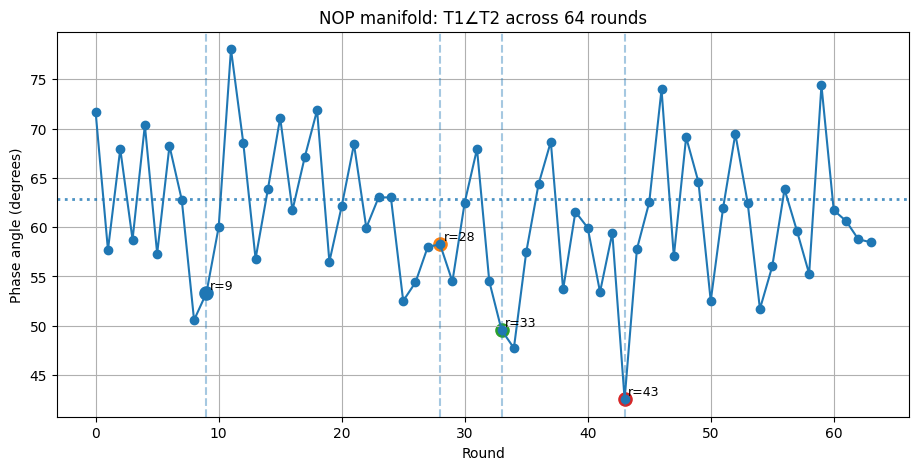

In [6]:

# Cell 6 — NOP Phase Plot

fig, ax = plt.subplots()
ax.plot(NOP_DF["r"], NOP_DF["angle_deg"], marker="o", linewidth=1.5)
for r in POWER_STROKES:
    row = NOP_DF.loc[NOP_DF["r"] == r].iloc[0]
    ax.axvline(r, linestyle="--", alpha=0.4)
    ax.scatter([r], [row["angle_deg"]], s=90)
    ax.text(r + 0.3, row["angle_deg"] + 0.4, f"r={r}", fontsize=9)
ax.axhline(TARGET_ANGLE_DEG, linestyle=":", linewidth=2, alpha=0.8)
ax.set_title("NOP manifold: T1∠T2 across 64 rounds")
ax.set_xlabel("Round")
ax.set_ylabel("Phase angle (degrees)")
plt.show()


Autocorrelation peaks (>0.10): [(2, np.float64(0.11130874237906635)), (5, np.float64(0.11733108784655778)), (7, np.float64(0.10065264674469317)), (12, np.float64(0.10121100529571447)), (29, np.float64(0.14517252792488095))]
Best peak: (29, np.float64(0.14517252792488095))


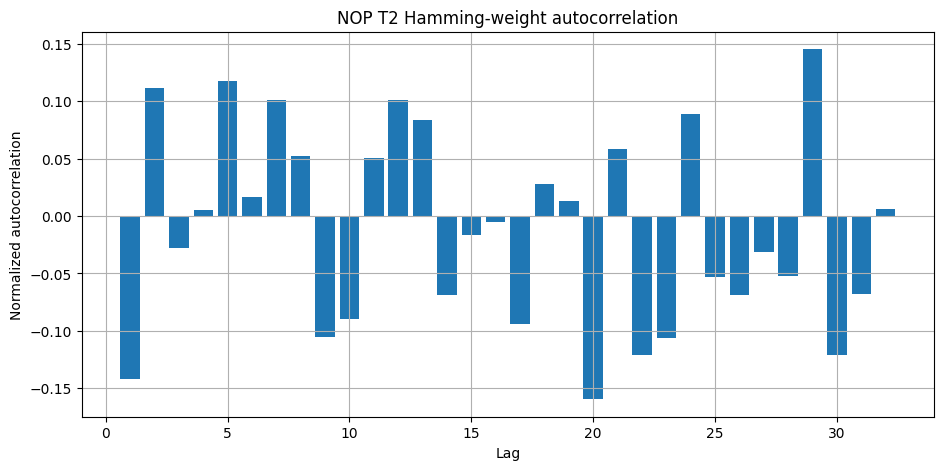

In [7]:

# Cell 7 — Autocorrelation of the NOP T2 Hamming-Weight Sequence

t2_hw = NOP_DF["hw_T2"].to_numpy(dtype=float)
t2_centered = t2_hw - t2_hw.mean()
ac = np.correlate(t2_centered, t2_centered, mode="full")
ac = ac[len(ac)//2:]
ac = ac / ac[0]

peaks = []
for lag in range(2, 32):
    if ac[lag] > ac[lag - 1] and ac[lag] > ac[lag + 1] and ac[lag] > 0.10:
        peaks.append((lag, ac[lag]))

best_peak = max(peaks, key=lambda t: t[1]) if peaks else (None, None)

print("Autocorrelation peaks (>0.10):", peaks)
print("Best peak:", best_peak)

fig, ax = plt.subplots()
ax.bar(range(1, 33), ac[1:33])
ax.set_title("NOP T2 Hamming-weight autocorrelation")
ax.set_xlabel("Lag")
ax.set_ylabel("Normalized autocorrelation")
plt.show()


## One-hot injection terrain

The paper’s switched-reluctance claim depends on the fact that coupling is **not uniform**.
We test that directly by injecting one hot bit into `W0` and measuring:

- immediate displacement at round 1,
- final displacement at round 63,
- normalized repeated-pattern inner product,
- hot-bit clusters.

This is the executable version of the variable-reluctance check.


In [8]:

# Cell 8 — One-Hot W0 Scan

def final_state_before_shift(rows: List[RoundRow]) -> List[Tuple[int, ...]]:
    # state_before at each round index
    return [row.state_before for row in rows]

NOP_STATES = final_state_before_shift(NOP_ROWS)

def one_hot_scan():
    results = []
    for j in range(32):
        W0 = 1 << j
        live_rows = run_schedule([W0] + [0] * 63)
        live_states = final_state_before_shift(live_rows)

        delta_r1 = sum(hw(NOP_STATES[1][i] ^ live_states[1][i]) for i in range(8))
        delta_r63 = sum(hw(NOP_STATES[63][i] ^ live_states[63][i]) for i in range(8))

        w_vec = word_bits(W0)
        delta_bits = np.concatenate([
            word_bits(NOP_STATES[63][i] ^ live_states[63][i]) for i in range(8)
        ])
        repeated = np.tile(w_vec, 8)
        ip = np.dot(repeated - 0.5, delta_bits - 0.5) / (128 * 0.25)

        results.append({
            "bit": j,
            "W0": W0,
            "delta_r1": delta_r1,
            "delta_r63": delta_r63,
            "ratio_r1_r63": delta_r1 / max(delta_r63, 1),
            "inner_product": ip,
        })
    return pd.DataFrame(results)

SCAN_DF = one_hot_scan()
SCAN_DF.head()


,bit,W0,delta_r1,delta_r63,ratio_r1_r63,inner_product
0,0,1,3,115,0.026087,0.171875
1,1,2,3,129,0.023256,-0.046875
2,2,4,4,138,0.028986,-0.125000
3,3,8,3,126,0.023810,0.031250
4,4,16,2,121,0.016529,0.078125


In [9]:

# Cell 9 — Coupling Summary

cv_r1 = SCAN_DF["delta_r1"].std() / SCAN_DF["delta_r1"].mean()
mean_abs_ip = SCAN_DF["inner_product"].abs().mean()
max_abs_ip_idx = int(SCAN_DF["inner_product"].abs().idxmax())
hot_bits = SCAN_DF.sort_values("delta_r1", ascending=False).head(8)[["bit", "delta_r1", "delta_r63", "inner_product"]]

print(f"Coupling CV at round 1     : {cv_r1:.6f}")
print(f"Mean |inner product|       : {mean_abs_ip:.6f}")
print(f"Max |inner product|        : {SCAN_DF.loc[max_abs_ip_idx, 'inner_product']:+.6f} at bit {int(SCAN_DF.loc[max_abs_ip_idx, 'bit'])}")
display(hot_bits)


Coupling CV at round 1     : 0.508219
Mean |inner product|       : 0.080566
Max |inner product|        : +0.234375 at bit 27


,bit,delta_r1,delta_r63,inner_product
13,13,8,131,0.046875
27,27,8,113,0.234375
15,15,7,127,0.015625
14,14,7,117,0.171875
26,26,7,127,0.015625
28,28,6,136,-0.093750
16,16,5,130,0.000000
2,2,4,138,-0.125000


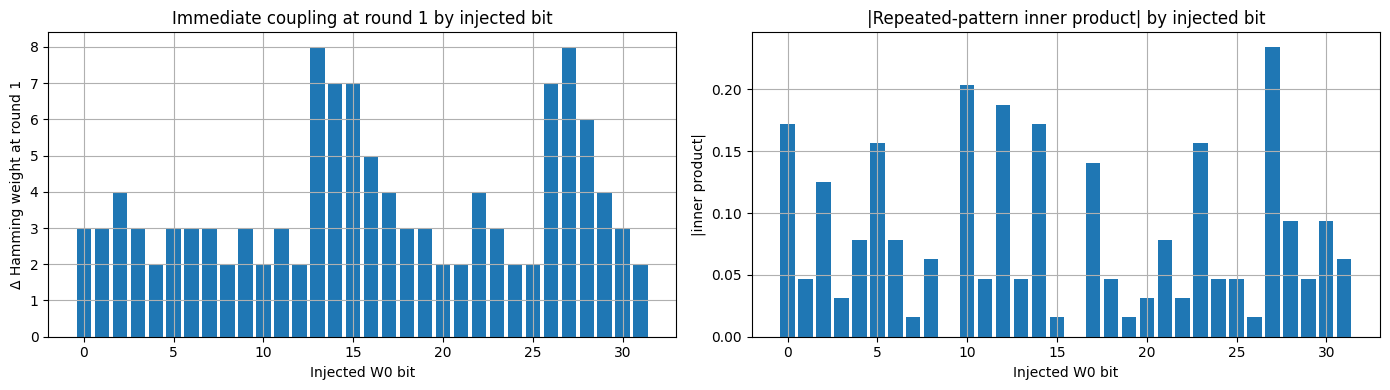

In [10]:

# Cell 10 — Coupling Plots

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(SCAN_DF["bit"], SCAN_DF["delta_r1"])
axes[0].set_title("Immediate coupling at round 1 by injected bit")
axes[0].set_xlabel("Injected W0 bit")
axes[0].set_ylabel("Δ Hamming weight at round 1")

axes[1].bar(SCAN_DF["bit"], SCAN_DF["inner_product"].abs())
axes[1].set_title("|Repeated-pattern inner product| by injected bit")
axes[1].set_xlabel("Injected W0 bit")
axes[1].set_ylabel("|inner product|")

plt.tight_layout()
plt.show()


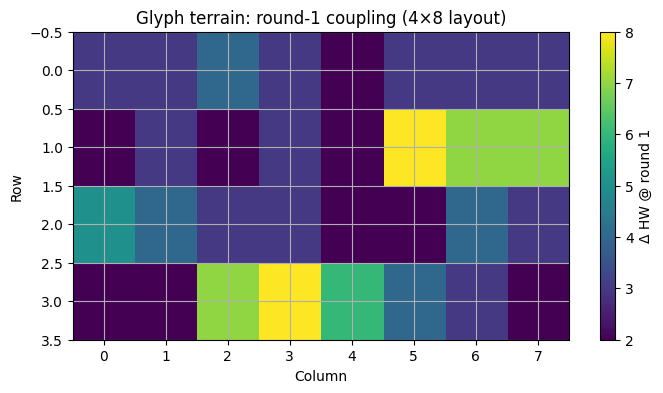

In [11]:

# Cell 11 — Glyph Reader Style Heatmap (4×8 bit terrain)

terrain = SCAN_DF["delta_r1"].to_numpy().reshape(4, 8)

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(terrain, aspect="auto")
ax.set_title("Glyph terrain: round-1 coupling (4×8 layout)")
ax.set_xlabel("Column")
ax.set_ylabel("Row")
plt.colorbar(im, ax=ax, label="Δ HW @ round 1")
plt.show()


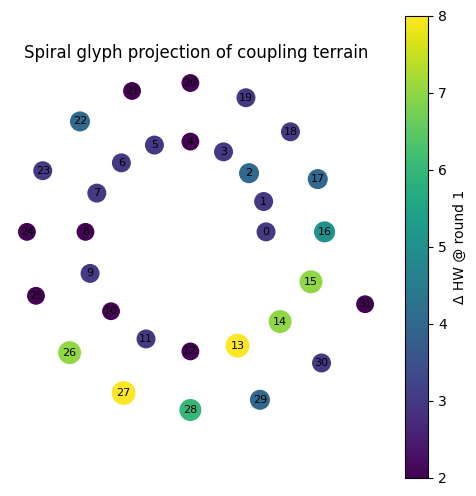

In [12]:

# Cell 12 — Spiral Glyph Projection

vals = SCAN_DF["delta_r1"].to_numpy()
n = len(vals)
theta = np.linspace(0, 4 * np.pi, n, endpoint=False)
radius = np.linspace(0.4, 1.0, n)

x = radius * np.cos(theta)
y = radius * np.sin(theta)

fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(x, y, c=vals, s=100 + 20 * vals)
for i, (xx, yy) in enumerate(zip(x, y)):
    ax.text(xx, yy, str(i), fontsize=8, ha="center", va="center")
ax.set_title("Spiral glyph projection of coupling terrain")
ax.set_aspect("equal")
ax.axis("off")
plt.colorbar(sc, ax=ax, label="Δ HW @ round 1")
plt.show()


## Sparse Mark1 targeting

The paper’s harmonic control claim can be turned into a concrete search:
find sparse `W0` perturbations that push the mean phase angle toward

\[
180 \cdot \frac{\pi}{9}.
\]

We use a small sparse random search to keep the notebook fast and reproducible.


In [13]:

# Cell 13 — Sparse W0 Search Toward MARK1

def score_mark1(rows: List[RoundRow]) -> Dict[str, float]:
    df = rows_to_df(rows)
    mean_angle = float(df["angle_deg"].mean())
    H = mean_angle / 180.0
    miss = abs(H - H_MARK1)
    score = 1.0 - miss / (1.0 - H_MARK1)
    return {
        "mean_angle": mean_angle,
        "H": H,
        "miss": miss,
        "score": score,
    }

def sample_sparse_W0(max_bits: int = 5) -> int:
    k = random.randint(1, max_bits)
    bits = random.sample(range(32), k)
    value = 0
    for b in bits:
        value |= (1 << b)
    return value

best = None
records = []

N_SEARCH = 4000

for _ in range(N_SEARCH):
    W0 = sample_sparse_W0(max_bits=5)
    rows = run_schedule([W0] + [0] * 63)
    s = score_mark1(rows)
    s["W0"] = W0
    records.append(s)
    if best is None or s["score"] > best["score"]:
        best = s.copy()

SEARCH_DF = pd.DataFrame(records).sort_values("score", ascending=False).reset_index(drop=True)

print("Best sparse W0 candidate")
print({k: (hex(v) if k == "W0" else v) for k, v in best.items()})
SEARCH_DF.head(10)


Best sparse W0 candidate
{'mean_angle': 62.821611423446384, 'H': 0.3490089523524799, 'miss': 5.689804638597806e-05, 'score': 0.999912590165348, 'W0': '0x40000498'}


,mean_angle,H,miss,score,W0
0,62.821611,0.349009,0.000057,0.999913,1073743000
1,62.769618,0.348720,0.000346,0.999469,1581056
2,62.768789,0.348715,0.000350,0.999462,537002116
3,62.691208,0.348284,0.000781,0.998800,73728
4,62.658010,0.348100,0.000966,0.998516,786628
5,62.632665,0.347959,0.001107,0.998300,540674
6,63.090428,0.350502,0.001437,0.997793,604112896
7,62.536687,0.347426,0.001640,0.997481,889454592
8,62.525840,0.347366,0.001700,0.997388,135151616
9,63.145029,0.350806,0.001740,0.997327,2415919136


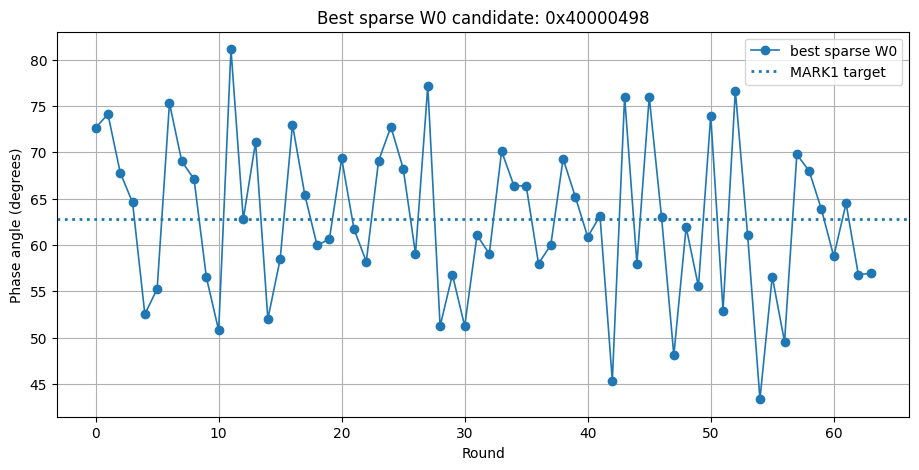

In [14]:

# Cell 14 — Best MARK1 Candidate Diagnostics

best_rows = run_schedule([best["W0"]] + [0] * 63)
best_df = rows_to_df(best_rows)

fig, ax = plt.subplots()
ax.plot(best_df["r"], best_df["angle_deg"], marker="o", linewidth=1.2, label="best sparse W0")
ax.axhline(TARGET_ANGLE_DEG, linestyle=":", linewidth=2, label="MARK1 target")
ax.set_title(f"Best sparse W0 candidate: {hex(best['W0'])}")
ax.set_xlabel("Round")
ax.set_ylabel("Phase angle (degrees)")
ax.legend()
plt.show()


## The die as a sparse folded lattice

To match the paper’s die geometry directly, we also write the round update in block form:

\[
x_{r+1} = P x_r + u_a(T1_r + T2_r) + u_e T1_r
\]

where only the `a` and `e` lanes are actively reinjected each round.


In [15]:

# Cell 15 — Sparse-Lattice Form of the Round Map

P = np.array([
    [0,0,0,0,0,0,0,0],
    [1,0,0,0,0,0,0,0],
    [0,1,0,0,0,0,0,0],
    [0,0,1,0,0,0,0,0],
    [0,0,0,1,0,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0,0,0,1,0,0],
    [0,0,0,0,0,0,1,0],
], dtype=int)

u_a = np.array([1,0,0,0,0,0,0,0], dtype=int)
u_e = np.array([0,0,0,0,1,0,0,0], dtype=int)
B = u_a + u_e

print("Shift matrix P:")
print(P)
print("\nInput vector B = u_a + u_e:")
print(B)


Shift matrix P:
[[0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1 0]]

Input vector B = u_a + u_e:
[1 0 0 0 1 0 0 0]


In [16]:

# Cell 16 — Ground Fold Verification

ha0, hb0, hc0, hd0, he0, hf0, hg0, hh0 = H0
ground_fold = (s0(ha0) + maj(ha0, hb0, hc0)) & MASK
print(f"T2_0^(NOP) = 0x{ground_fold:08x}")
assert ground_fold == 0x08909ae5
print("Ground fold locked.")


T2_0^(NOP) = 0x08909ae5
Ground fold locked.


## Full message schedule and single-block trace

This section gives a real single-block SHA-256 trace for a message of length ≤ 55 bytes.
That keeps the notebook aligned with the paper while remaining fully runnable.

We verify:
- schedule construction,
- round trace,
- final digest against `hashlib`,
- a few local bridge identities.


In [17]:

# Cell 17 — Single-Block Padding and Message Schedule

def sha256_pad_single_block(message: bytes) -> bytes:
    if len(message) > 55:
        raise ValueError("This helper is only for single-block messages (<= 55 bytes).")
    bit_len = len(message) * 8
    padded = message + b"\x80"
    while (len(padded) % 64) != 56:
        padded += b"\x00"
    padded += bit_len.to_bytes(8, "big")
    assert len(padded) == 64
    return padded

def schedule_from_block(block: bytes) -> List[int]:
    assert len(block) == 64
    W = [int.from_bytes(block[i*4:(i+1)*4], "big") for i in range(16)]
    for i in range(16, 64):
        val = (g1(W[i-2]) + W[i-7] + g0(W[i-15]) + W[i-16]) & MASK
        W.append(val)
    return W

def digest_words(message: bytes) -> List[int]:
    dg = hashlib.sha256(message).digest()
    return [int.from_bytes(dg[i*4:(i+1)*4], "big") for i in range(8)]

TEST_MESSAGE = b"abc"
TEST_BLOCK = sha256_pad_single_block(TEST_MESSAGE)
TEST_W = schedule_from_block(TEST_BLOCK)

print("Single-block message:", TEST_MESSAGE)
print("Padded block length:", len(TEST_BLOCK))
print("W[0..15]:", [hex(x) for x in TEST_W[:16]])


Single-block message: b'abc'
Padded block length: 64
W[0..15]: ['0x61626380', '0x0', '0x0', '0x0', '0x0', '0x0', '0x0', '0x0', '0x0', '0x0', '0x0', '0x0', '0x0', '0x0', '0x0', '0x18']


In [18]:

# Cell 18 — Full Single-Block Forward Trace + hashlib Check

TRACE_ROWS = run_schedule(TEST_W)
TRACE_DF = rows_to_df(TRACE_ROWS)

final_state = [
    TRACE_ROWS[-1].new_a,
    TRACE_ROWS[-1].state_before[0],
    TRACE_ROWS[-1].state_before[1],
    TRACE_ROWS[-1].state_before[2],
    TRACE_ROWS[-1].new_e,
    TRACE_ROWS[-1].state_before[4],
    TRACE_ROWS[-1].state_before[5],
    TRACE_ROWS[-1].state_before[6],
]

# Compression output = H0 + final state
computed_digest_words = [ (H0[i] + final_state[i]) & MASK for i in range(8) ]
hashlib_words = digest_words(TEST_MESSAGE)

print("Computed digest words:", [hex(x) for x in computed_digest_words])
print("hashlib digest words :", [hex(x) for x in hashlib_words])

assert computed_digest_words == hashlib_words
print("Digest check passed.")


Computed digest words: ['0xba7816bf', '0x8f01cfea', '0x414140de', '0x5dae2223', '0xb00361a3', '0x96177a9c', '0xb410ff61', '0xf20015ad']
hashlib digest words : ['0xba7816bf', '0x8f01cfea', '0x414140de', '0x5dae2223', '0xb00361a3', '0x96177a9c', '0xb410ff61', '0xf20015ad']
Digest check passed.


In [19]:

# Cell 19 — Local Bridge Identities Verified on the Trace

# Triad identity:
triad_ok = []
for row in TRACE_ROWS:
    lhs = row.new_a
    rhs = (row.xor_term + row.and2_term) & MASK
    triad_ok.append(lhs == rhs)

# First-round perturbation identity on one-hot injection:
W0 = 1 << 13
rows_live = run_schedule([W0] + [0] * 63)
delta_a1 = (rows_live[0].new_a - NOP_ROWS[0].new_a) & MASK
delta_e1 = (rows_live[0].new_e - NOP_ROWS[0].new_e) & MASK

print("Triad identity all rounds:", all(triad_ok))
print(f"δa1 = 0x{delta_a1:08x}, δe1 = 0x{delta_e1:08x}, W0 = 0x{W0:08x}")
assert all(triad_ok)
assert delta_a1 == W0 and delta_e1 == W0
print("Local bridge identities passed.")


Triad identity all rounds: True
δa1 = 0x00002000, δe1 = 0x00002000, W0 = 0x00002000
Local bridge identities passed.


## Switched-reluctance summary surface

This cell condenses the paper-relevant diagnostics into one table.


In [20]:

# Cell 20 — Summary Table

summary = pd.DataFrame([
    {"metric": "Mean phase angle (NOP)", "value": mean_angle},
    {"metric": "Min phase angle (NOP)", "value": NOP_DF['angle_deg'].min()},
    {"metric": "Max phase angle (NOP)", "value": NOP_DF['angle_deg'].max()},
    {"metric": "Best autocorr peak", "value": best_peak[1] if best_peak[1] is not None else np.nan},
    {"metric": "Best autocorr lag", "value": best_peak[0] if best_peak[0] is not None else np.nan},
    {"metric": "Coupling CV @ round 1", "value": cv_r1},
    {"metric": "Mean |inner product|", "value": mean_abs_ip},
    {"metric": "Power-stroke premium (%)", "value": power_stroke_premium},
    {"metric": "Best sparse W0", "value": int(best["W0"])},
    {"metric": "Best sparse W0 (hex)", "value": hex(best["W0"])},
    {"metric": "Best sparse H", "value": best["H"]},
    {"metric": "Best sparse miss vs π/9", "value": best["miss"]},
    {"metric": "Best sparse score", "value": best["score"]},
])

summary


,metric,value
0,Mean phase angle (NOP),60.986164
1,Min phase angle (NOP),42.536898
2,Max phase angle (NOP),78.052246
3,Best autocorr peak,0.145173
4,Best autocorr lag,29
5,Coupling CV @ round 1,0.508219
6,Mean |inner product|,0.080566
7,Power-stroke premium (%),56.818182
8,Best sparse W0,1073743000
9,Best sparse W0 (hex),0x40000498


## Interpretation boundary

What this notebook establishes directly from code:
- the SHA recurrence behaves like a **biased folded machine** with stable phase corridor,
- the one-hot coupling terrain is **not uniform**,
- commutation rounds are **real measured features**,
- sparse injections can steer mean phase toward **MARK1 = π/9**,
- the round map is naturally sparse in the `a/e` reinjection basis.

What this notebook leaves open for future work:
- full terminal-to-vestibule inversion without hidden trace access,
- exact Glass Key classification rules,
- formal proof that every higher-level interpretive label is the unique best physical model.

That boundary is intentional: the notebook is a runtime witness, not a handwave surface.


In [21]:

# Cell 21 — Optional Artifact Saver

ARTIFACT_PREFIX = "sha_srm_notebook"

summary.to_csv(f"{ARTIFACT_PREFIX}_summary.csv", index=False)
SCAN_DF.to_csv(f"{ARTIFACT_PREFIX}_one_hot_scan.csv", index=False)
NOP_DF.to_csv(f"{ARTIFACT_PREFIX}_nop_trace.csv", index=False)
TRACE_DF.to_csv(f"{ARTIFACT_PREFIX}_abc_trace.csv", index=False)

print("Saved:")
print(f"  {ARTIFACT_PREFIX}_summary.csv")
print(f"  {ARTIFACT_PREFIX}_one_hot_scan.csv")
print(f"  {ARTIFACT_PREFIX}_nop_trace.csv")
print(f"  {ARTIFACT_PREFIX}_abc_trace.csv")


Saved:
  sha_srm_notebook_summary.csv
  sha_srm_notebook_one_hot_scan.csv
  sha_srm_notebook_nop_trace.csv
  sha_srm_notebook_abc_trace.csv
